Logistic Regression Project (Predict Ad click)

source: https://www.kaggle.com/code/faressayah/logistic-regression-for-binary-classification-task

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

plt.style.use("fivethirtyeight")

data =pd.read_csv('advertising.csv')

In [6]:
data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 78.3 KB


In [9]:
data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


1. Exploratory data analysis

Text(0.5, 0, 'Age')

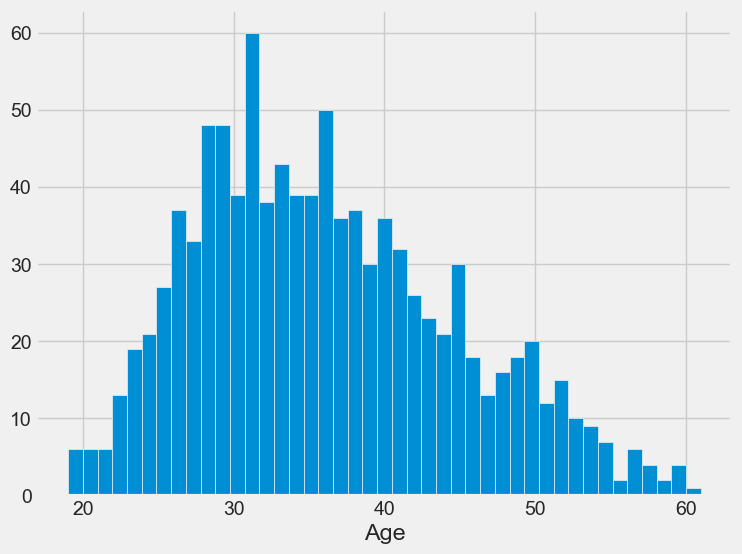

In [14]:
plt.figure(figsize=(8,6))
data.Age.hist(bins=data.Age.nunique())
plt.xlabel('Age')

<Figure size 800x600 with 0 Axes>

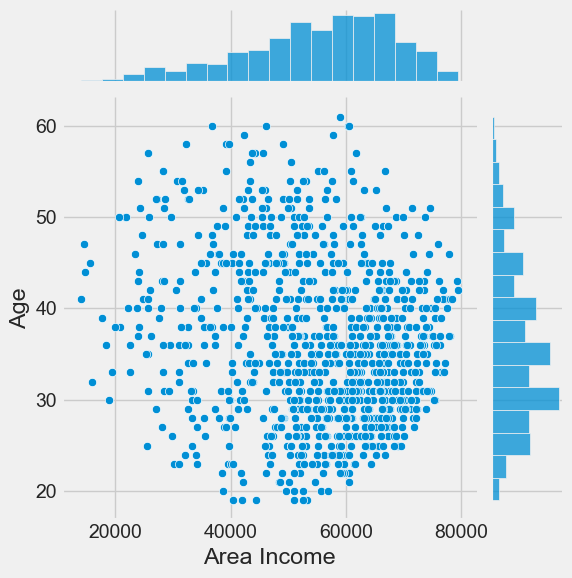

In [15]:
plt.figure(figsize=(8,6))
sns.jointplot(x=data['Area Income'], y=data.Age)

<Figure size 800x700 with 0 Axes>

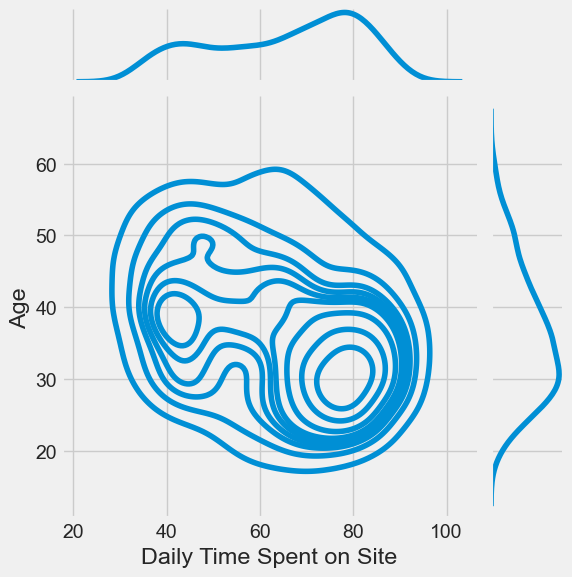

In [16]:
plt.figure(figsize=(8,7))
sns.jointplot(x=data['Daily Time Spent on Site'], y=data.Age, kind='kde')

<Figure size 800x700 with 0 Axes>

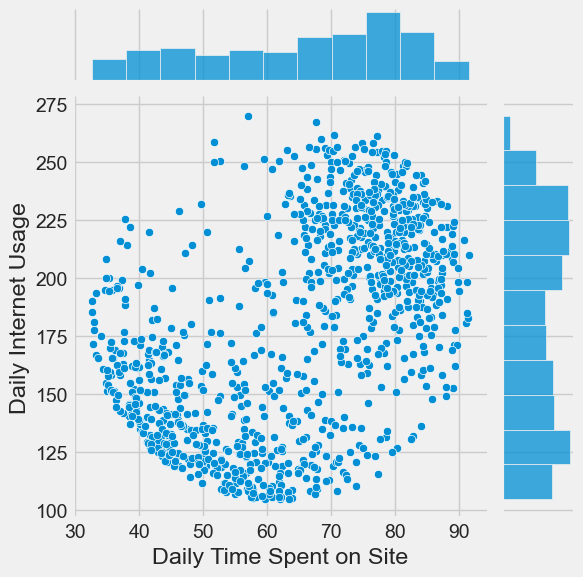

In [17]:
plt.figure(figsize=(8,7))
sns.jointplot(x=data['Daily Time Spent on Site'], y=data['Daily Internet Usage'])

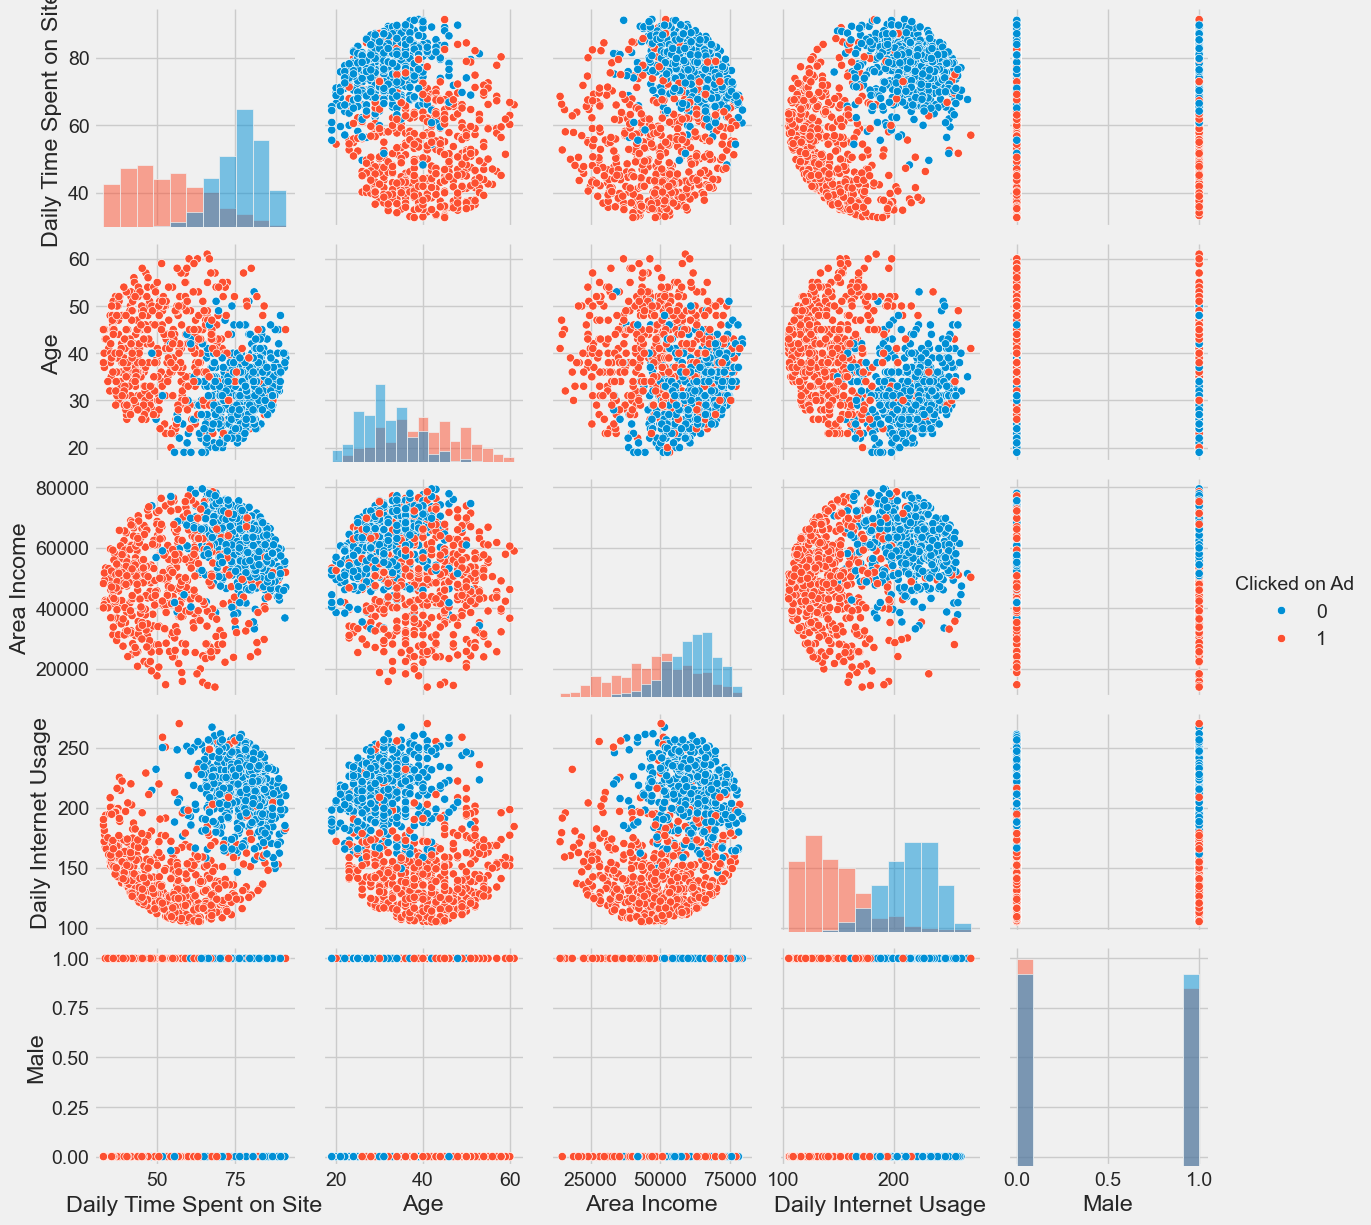

In [19]:
sns.pairplot(data, hue='Clicked on Ad', diag_kind='hist')

#Tip: You can change what appears on the diagonal by passing diag_kind='hist' or diag_kind='kde' inside sns.pairplot(...)

In [20]:
data['Clicked on Ad'].value_counts()

Clicked on Ad
0    500
1    500
Name: count, dtype: int64

<Axes: >

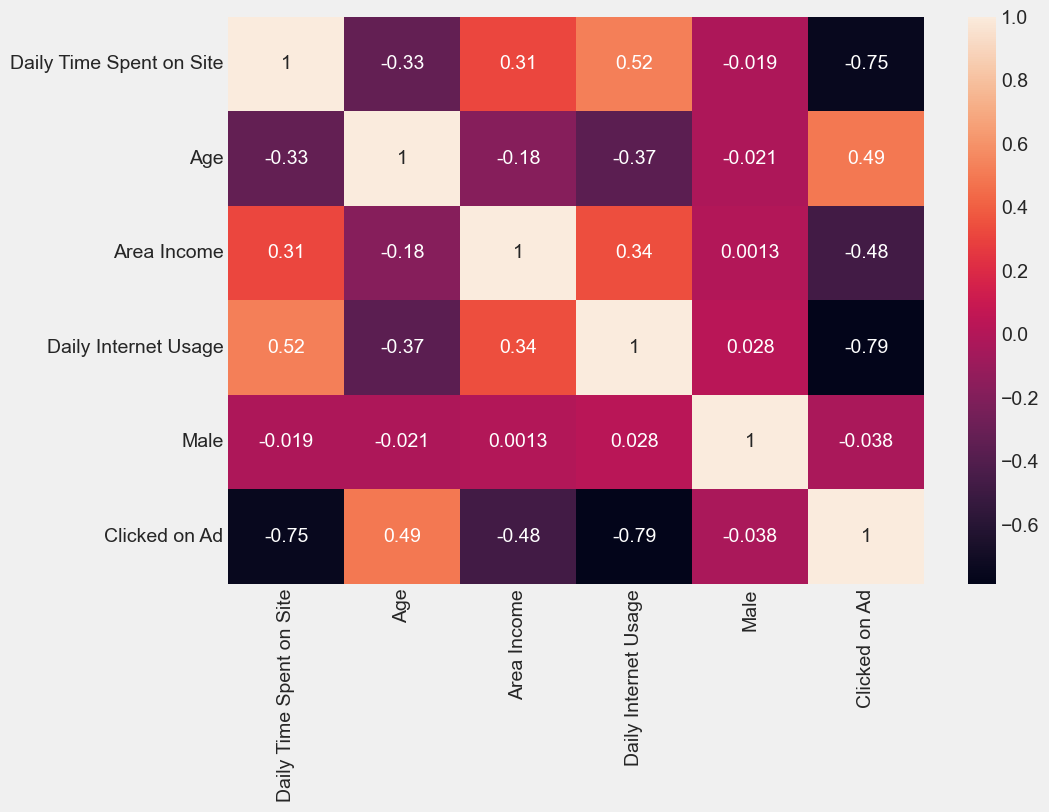

In [22]:
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(numeric_only=True), annot=True)

Text(0.5, 1.0, 'plot sigmoid function')

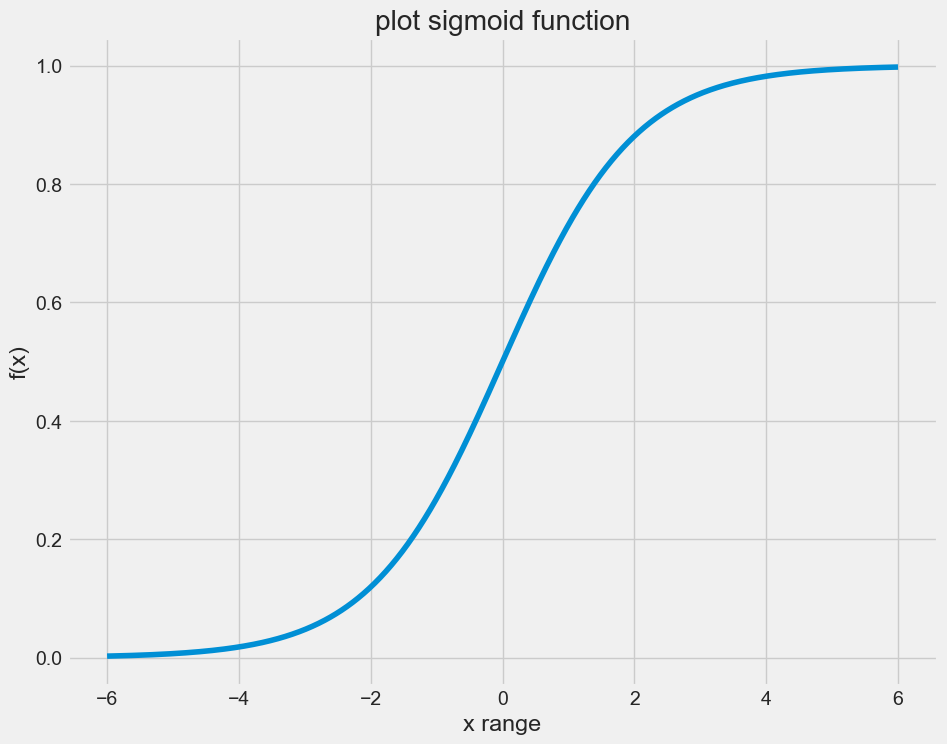

In [23]:
x= np.linspace(-6,6, num=1000)
plt.figure(figsize=(10,8))
plt.plot(x, (1/(1+np.exp(-x))))

plt.xlabel('x range')
plt.ylabel('f(x)')
plt.title('plot sigmoid function')

The logistic regression equation has a very similar representation like linear regression. The difference is that the output value being modelled is binary in nature.

$$
\hat{y} = \frac{e^{\beta_0 + \beta_1x_1}}{1 + e^{\beta_0 + \beta_1x_1}}
$$

or

$$
\hat{y} = \frac{1.0}{1.0 + e^{-\beta_0 - \beta_1x_1}}
$$

- $\beta_0$ is the intercept term

- $\beta_1$ is the coefficient for $x_1$

- $\hat{y}$ is the predicted output with real value between 0 and 1. To convert this to binary output of 0 or 1, this would either need to be rounded to an integer value or a cutoff point be provided to specify the class segregation point.

## Logistic Regression Equation

The logistic regression equation has a very similar representation like linear regression. The difference is that the output value being modelled is binary in nature.

$$
\hat{y} = \frac{e^{\beta_0 + \beta_1x_1}}{1 + e^{\beta_0 + \beta_1x_1}}
$$

or

$$
\hat{y} = \frac{1.0}{1.0 + e^{-\beta_0 - \beta_1x_1}}
$$

- $\beta_0$ is the intercept term.
- $\beta_1$ is the coefficient for $x_1$.
- $\hat{y}$ is the predicted output with a real value between 0 and 1. To convert this to a binary output of 0 or 1, the predicted probability must either be rounded to an integer value or a cutoff point (threshold) must be provided to specify the class segregation point.

---

## Learning the Logistic Regression Model

The coefficients (Beta values, $\beta$) of the logistic regression algorithm must be estimated from your training data. This is done using **maximum-likelihood estimation (MLE)**.

Maximum-likelihood estimation is a common learning algorithm used by a variety of machine learning algorithms, although it does make assumptions about the distribution of your data (more on this when discussing data preparation).

The best coefficients result in a model that predicts a value very close to **1** (e.g., *male*) for the positive class and a value very close to **0** (e.g., *female*) for the negative class.

The intuition behind maximum-likelihood estimation for logistic regression is that a search procedure seeks coefficient values (Beta values) that minimize the error between the probabilities predicted by the model and the actual class labels in the training data (e.g., a probability close to **1** when the true class is the positive class).

We are not going to go into the mathematics of maximum likelihood. It is enough to know that a **minimization algorithm** is used to optimize the best values for the coefficients using the training data. In practice, this is often implemented using efficient numerical optimization algorithms such as the **Quasi-Newton method**.

When learning logistic regression, you can also implement it yourself from scratch using the much simpler **Gradient Descent** algorithm.

In [ ]:
from sklearn.metrics import  accuracy_score, confusion_matrix, classification_report



Reasons of using scikit-learn (not pandas) for ML preprocessing:

You can cross-validate the entire workflow.
You can grid search model & preprocessing hyperparameters.
Avoids adding new columns to the source DataFrame.
Pandas lacks separate fit/transform steps to prevent data leakage.

In [ ]:
from sklearn.preprocessing import  StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.compose import make_column_transformer

from sklearn.model_selection import train_test_split

In [26]:
X= data.drop(['Timestamp', 'Clicked on Ad','Ad Topic Line', 'Country', 'City'], axis=1)

In [27]:
X

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male
0,68.95,35,61833.90,256.09,0
1,80.23,31,68441.85,193.77,1
2,69.47,26,59785.94,236.50,0
3,74.15,29,54806.18,245.89,1
4,68.37,35,73889.99,225.58,0
...,...,...,...,...,...
995,72.97,30,71384.57,208.58,1
996,51.30,45,67782.17,134.42,1
997,51.63,51,42415.72,120.37,1
998,55.55,19,41920.79,187.95,0


In [28]:
y=data['Clicked on Ad']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
# num_columns = []
num_columns = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']

In [31]:
ct = make_column_transformer(
    (MinMaxScaler(), num_columns),
    (StandardScaler(), num_columns),
    remainder='passthrough'
)

In [34]:
X_train =ct.fit_transform(X_train)
X_test= ct.transform(X_test)

## 3. Prepare Data for Logistic Regression

The assumptions made by logistic regression about the distribution and relationships in your data are much the same as the assumptions made in linear regression.

Much study has gone into defining these assumptions, and precise probabilistic and statistical language is used. My advice is to use these as guidelines or rules of thumb and experiment with different data preparation schemes.

Ultimately, in predictive modeling and machine learning projects, you are laser-focused on making accurate predictions rather than interpreting the results. As such, you can break some assumptions as long as the model is robust and performs well.

### Assumptions and Data Preparation Guidelines

#### 1. Binary Output Variable

This might be obvious, but logistic regression is intended for **binary (two-class) classification** problems. It predicts the probability of an instance belonging to the positive (default) class, which can then be converted into a **0** or **1** classification using a threshold.

#### 2. Remove Noise

Logistic regression assumes there is **no error in the output variable ($y$)**. Consider removing:

- Outliers
- Misclassified instances
- Noisy observations

from your training data whenever possible.

#### 3. Gaussian Distribution

Logistic regression is a **linear algorithm** (with a non-linear transformation applied to the output). It assumes a **linear relationship** between the input variables and the output.

Applying transformations to the input variables can help expose this relationship and improve model performance. Common transformations include:

- Log transformation
- Square root transformation
- Box-Cox transformation
- Other univariate transformations

#### 4. Remove Correlated Inputs

Like linear regression, logistic regression can **overfit** when multiple input variables are highly correlated (**multicollinearity**).

Consider:

- Calculating pairwise correlations between input features.
- Removing highly correlated variables before training.

#### 5. Fail to Converge

The maximum-likelihood estimation process used to learn the model coefficients may **fail to converge**.

This commonly occurs when:

- Many input variables are highly correlated.
- The dataset is very sparse (e.g., contains many zero values).

Proper feature selection and preprocessing can often resolve convergence issues.

In [38]:
#implementing Logictic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred =clf.predict(X_test)

In [41]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred)*100)
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       146
           1       0.98      0.96      0.97       154

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

97.0
[[143   3]
 [  6 148]]


Now we will test with Random Forest classifier as well


In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_clf =RandomForestClassifier(n_estimators=1000)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       146
           1       0.97      0.95      0.96       154

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

0.9566666666666667
[[141   5]
 [  8 146]]


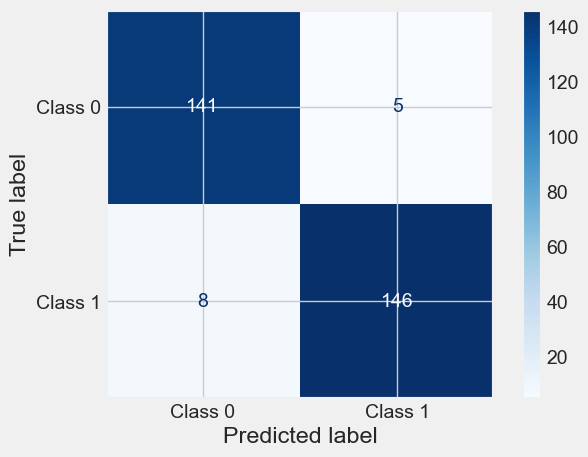

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot directly from predictions
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_rf, 
    display_labels=['Class 0', 'Class 1'], # Replace with your class names
    cmap=plt.cm.Blues
)
plt.show()


# 5. Performance Measurement

## 1. Confusion Matrix

A **Confusion Matrix** summarizes the performance of a classification model.

- **Each row** represents the **actual class**.
- **Each column** represents the **predicted class**.

### First Row: Non-clicked Ads (Negative Class)

- **143** were correctly classified as **Non-clicked Ads** → **True Negatives (TN)**
- **6** were incorrectly classified as **Clicked Ads** → **False Positives (FP)**

### Second Row: Clicked Ads (Positive Class)

- **3** were incorrectly classified as **Non-clicked Ads** → **False Negatives (FN)**
- **146** were correctly classified as **Clicked Ads** → **True Positives (TP)**

---

## 2. Precision

**Precision** measures the accuracy of positive predictions made by the classifier.

> **Precision =** True Positives / (True Positives + False Positives)

$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

**Result:** `98.01%`

---

## 3. Recall

**Recall** (also called **Sensitivity** or **True Positive Rate**) measures the proportion of actual positive instances that are correctly identified by the classifier.

> **Recall =** True Positives / (True Positives + False Negatives)

$$
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

**Result:** `96.10%`

---

## 4. F1 Score

The **F1 Score** is the harmonic mean of **Precision** and **Recall**.

Unlike the arithmetic mean, the harmonic mean gives more weight to lower values, making the F1 Score useful when balancing Precision and Recall.

$$
F_1 = \frac{2}{\frac{1}{\text{Precision}} + \frac{1}{\text{Recall}}}
$$

Equivalent formula:

$$
F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Or directly in terms of the confusion matrix:

$$
F_1 = \frac{2 \times \text{TP}}{2 \times \text{TP} + \text{FP} + \text{FN}}
$$

**Result:** `97.05%`

The **F1 Score** favors classifiers that have similar Precision and Recall values.

---

## 5. Precision / Recall Tradeoff

There is usually a tradeoff between Precision and Recall:

- Increasing **Precision** generally **reduces Recall**.
- Increasing **Recall** generally **reduces Precision**.

The optimal balance depends on the problem being solved.

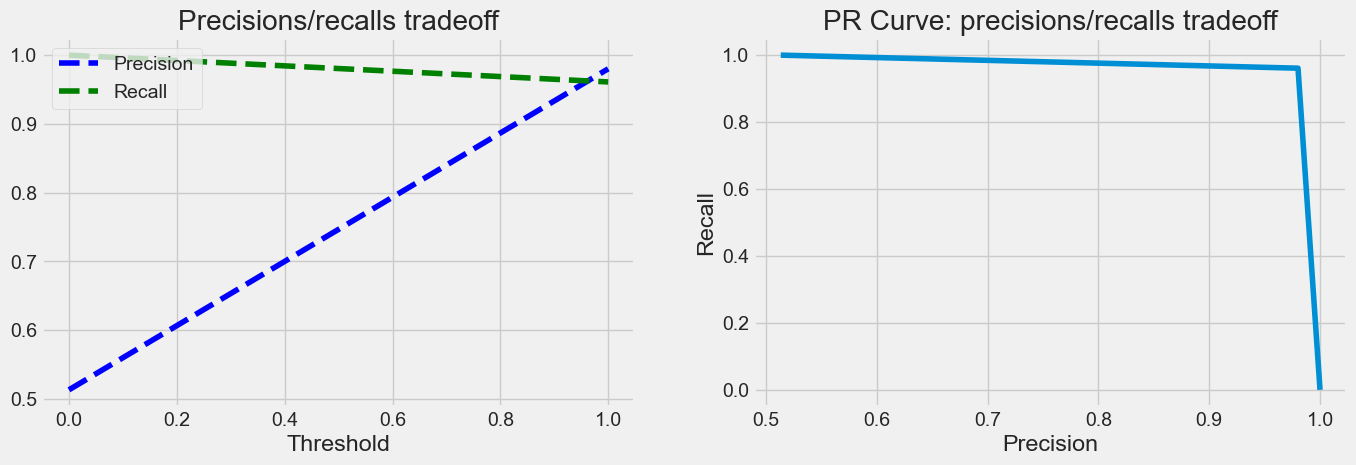

In [49]:
from sklearn.metrics import precision_recall_curve


def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.title("Precisions/recalls tradeoff")

    
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred)


plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

plt.subplot(2, 2, 2)
plt.plot(precisions, recalls)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("PR Curve: precisions/recalls tradeoff");

With this chart, you can select the threshold value that gives you the best precision/recall tradeoff for your task.

Some tasks may call for higher precision (accuracy of positive predictions). Like designing a classifier that picks up adult contents to protect kids. This will require the classifier to set a high bar to allow any contents to be consumed by children.

Some tasks may call for higher recall (ratio of positive instances that are correctly detected by the classifier). Such as detecting shoplifters/intruders on surveillance images - Anything that remotely resemble "positive" instances to be picked up.

## The Receiver Operating Characteristics (ROC) Curve 

The Receiver Operating Characteristics (ROC) Curve
Instead of plotting precision versus recall, the ROC curve plots the true positive rate (another name for recall) against the false positive rate. The false positive rate (FPR) is the ratio of negative instances that are incorrectly classified as positive. It is equal to one minus the true negative rate, which is the ratio of negative instances that are correctly classified as negative.

The TNR is also called specificity. Hence the ROC curve plots sensitivity (recall) versus 1 - specificity.

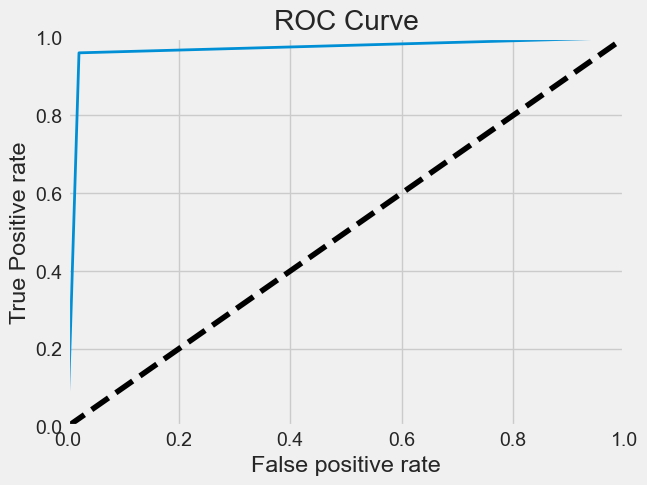

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds =roc_curve(y_test, y_pred)
plt.Figure(figsize=(10,6))
plt.plot(fpr, tpr, linewidth=2, label=None)
plt.plot([0, 1], [0, 1], "k--")
plt.axis([0, 1, 0, 1])

plt.xlabel('False positive rate')
plt.ylabel('True Positive rate')
plt.title('ROC Curve')
plt.show()


In [56]:
roc_auc_score(y_test, y_pred)

0.9702455079167409

Use PR curve whenever the positive class is rare or when you care more about the false positives than the false negatives

Use ROC curve whenever the negative class is rare or when you care more about the false negatives than the false positives

In the example above, the ROC curve seemed to suggest that the classifier is good. However, when you look at the PR curve, you can see that there are room for improvement.

## 6. Hyper Parameter tuning in Logistic Regression


In [59]:
from sklearn.model_selection import  GridSearchCV

lr_clf = LogisticRegression()

penalty =['l1','l2']

C = [0.5,0.6,0.7,0.8]

class_weight = [{1:0.5, 0:0.5}, {1:0.4, 0:0.6}, {1:0.6, 0:0.4}, {1:0.7, 0:0.3}]
solver = ['liblinear', 'saga']


param_grid =dict(
    penalty=penalty,
    C=C,
    class_weight=class_weight,
    solver=solver
)

lr_cv = GridSearchCV(
    estimator=lr_clf,
    param_grid=param_grid,
    scoring= 'f1',
    verbose=1,
    n_jobs=-1, cv=10
)

lr_cv.fit(X_train,y_train)
best_params = lr_cv.best_params_
print(f" best paramets:{best_params}")

lr_clf1= LogisticRegression(**best_params)
lr_clf1.fit(X_train, y_train)

y_pred_cv=lr_clf1.predict(X_test)

Fitting 10 folds for each of 64 candidates, totalling 640 fits
 best paramets:{'C': 0.6, 'class_weight': {1: 0.5, 0: 0.5}, 'penalty': 'l2', 'solver': 'saga'}


c:\Users\sujat\projects\ML\myvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sujat\projects\ML\myvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [60]:
print(accuracy_score(y_test,y_pred_cv))
print(confusion_matrix(y_test, y_pred_cv))

0.97
[[144   2]
 [  7 147]]


# Logistic Regression Hyperparameters

## 1. `penalty`

Controls the type of **regularization** applied to the model. Regularization helps prevent overfitting by penalizing large coefficients.

| Value | Description | When to Use |
|--------|-------------|-------------|
| `'l1'` | **Lasso Regularization**. Adds the absolute value of coefficients to the loss function. Can shrink some coefficients to exactly **0**, effectively performing feature selection. | Useful when you have many features and believe only a subset is important. |
| `'l2'` | **Ridge Regularization**. Adds the squared value of coefficients to the loss function. Shrinks coefficients toward zero but rarely makes them exactly zero. | Default choice for most classification problems. |

**Example:**
```python
penalty = ['l1', 'l2']
```

---

## 2. `C`

Controls the **strength of regularization**.

- `C` is the **inverse** of regularization strength.

| C Value | Regularization | Model Complexity |
|---------:|----------------|------------------|
| Small (e.g., 0.1) | Strong | Simpler model, less overfitting |
| Medium (0.5–1.0) | Moderate | Balanced |
| Large (10, 100) | Weak | More complex model, may overfit |

In your grid:

```python
C = [0.5, 0.6, 0.7, 0.8]
```

These values test different levels of regularization.

- `0.5` → Stronger regularization
- `0.8` → Weaker regularization

---

## 3. `class_weight`

Assigns different importance (weights) to each class during training.

This is especially useful for **imbalanced datasets**.

### Syntax

```python
class_weight = {class_label: weight}
```

For example:

```python
{1:0.5, 0:0.5}
```

means both classes are treated equally.

Your parameter grid:

```python
class_weight = [
    {1:0.5, 0:0.5},
    {1:0.4, 0:0.6},
    {1:0.6, 0:0.4},
    {1:0.7, 0:0.3}
]
```

| Class Weight | Meaning |
|--------------|---------|
| `{1:0.5, 0:0.5}` | Equal importance to both classes. |
| `{1:0.4, 0:0.6}` | Class **0** is given more importance than class **1**. |
| `{1:0.6, 0:0.4}` | Class **1** is given more importance. |
| `{1:0.7, 0:0.3}` | Strong emphasis on correctly predicting class **1**. |

### Example

Suppose:

- Class 0 = Not Fraud
- Class 1 = Fraud

Using:

```python
class_weight = {0:0.3, 1:0.7}
```

means the model is penalized more when it misclassifies fraudulent transactions.

---

## 4. `solver`

The optimization algorithm used to find the best model parameters.

Different solvers support different penalties and dataset sizes.

Your grid:

```python
solver = ['liblinear', 'saga']
```

| Solver | Supports | Best For |
|---------|----------|----------|
| `'liblinear'` | L1, L2 | Small to medium datasets. Binary classification. |
| `'saga'` | L1, L2, ElasticNet | Large datasets, sparse data, multinomial logistic regression. |

### Comparison

| Feature | liblinear | saga |
|---------|-----------|------|
| L1 Regularization | ✅ | ✅ |
| L2 Regularization | ✅ | ✅ |
| ElasticNet | ❌ | ✅ |
| Multiclass | Limited (One-vs-Rest) | Native support |
| Large Datasets | Slower | Faster |
| Sparse Data | Good | Excellent |

---

# Total Number of Parameter Combinations

Given:

```python
penalty = ['l1', 'l2']                  # 2 options
C = [0.5,0.6,0.7,0.8]                   # 4 options
class_weight = [4 dictionaries]         # 4 options
solver = ['liblinear','saga']           # 2 options
```

Total combinations:

```text
2 × 4 × 4 × 2 = 64 combinations
```

If using **5-fold cross-validation**, the model will be trained:

```text
64 × 5 = 320 times
```

---

# Example GridSearchCV

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "penalty": ['l1', 'l2'],
    "C": [0.5, 0.6, 0.7, 0.8],
    "class_weight": [
        {1:0.5, 0:0.5},
        {1:0.4, 0:0.6},
        {1:0.6, 0:0.4},
        {1:0.7, 0:0.3}
    ],
    "solver": ['liblinear', 'saga']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
```

---

# Summary

| Hyperparameter | Purpose | Typical Choices |
|----------------|---------|-----------------|
| `penalty` | Type of regularization | `'l1'`, `'l2'` |
| `C` | Inverse of regularization strength | `0.1–10` |
| `class_weight` | Importance assigned to each class | `None`, `'balanced'`, custom dictionary |
| `solver` | Optimization algorithm | `'liblinear'`, `'lbfgs'`, `'saga'`, `'newton-cg'`, `'newton-cholesky'` |

## 7.Summary

In this Notebook you discovered the logistic regression algorithm for machine learning and predictive modeling. You covered a lot of ground and learned:

What the logistic function is and how it is used in logistic regression.
That the key representation in logistic regression are the coefficients, just like linear regression.
That the coefficients in logistic regression are estimated using a process called maximum-likelihood estimation.
That making predictions using logistic regression is so easy that you can do it in excel.
That the data preparation for logistic regression is much like linear regression.
How to evaluate a machine learning classification problem.
How to tune logistic regression hyperparameters.